# Image recognition

I will be doing a image recognition program in raw PyTorch, i will build a conventional CNN (convolutional neural network) that can actually classify photos and every piece will connect directly to what is already written

Data will be trained on MNIST (handwritten digits, 60k images) 

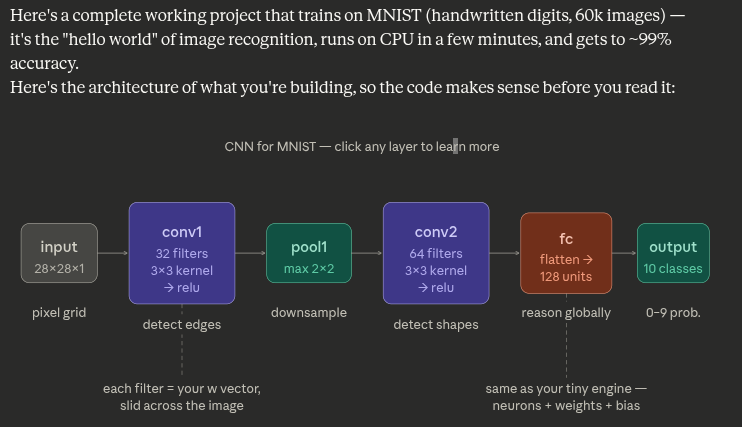

In [3]:
import torch
     
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")
device = torch.device("cuda")

NVIDIA GeForce RTX 4070 Ti SUPER
16.71102464 GB


The hardware i will be using to train the model

In [4]:
from torchvision import datasets, transforms

device = torch.device("cuda")

transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
# The data itself stays on CPU - only tensors that we will be computing move on to the GPU
# the DataLoader handles feeding batches, we'll move those when we get to training

In [11]:
print(len(train_data)) # how many images?
print(train_data[0]) # what does one sample look like?

60000
(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 

In [12]:
print(train_data[0][0].shape) # what shape is the tensor?
print(train_data[0][0].min(), train_data[0][0].max())  # pixel value range
print(train_data[0][1]) # what's the label?

torch.Size([1, 28, 28])
tensor(0.) tensor(1.)
5


The shape [1, 28, 28] means [channels, height, width]. The 1 is because MNIST is greyscale — one colour channel. When you move to colour images (like cats vs dogs) that becomes [3, 28, 28] for RGB. The conv layer will need to know this number.

In [14]:
img, label = train_data[0]

# img is shape [1, 28, 28] — squeeze out the channel dimension
pixels = img.squeeze().numpy()

for row in pixels:
    print("".join("##" if p > 0.5 else "  " for p in row))

print(f"Label: {label}")

                                                        
                                                        
                                                        
                                                        
                                                        
                                  ####  ######          
                      ########################          
                ####################                    
                ####################                    
                  ##  ######      ##                    
                      ####                              
                      ######                            
                        ####                            
                          ######                        
                            ######                      
                              ########                  
                                  ######                
                               

This is supposed to look like number 2 but here i doesn't really 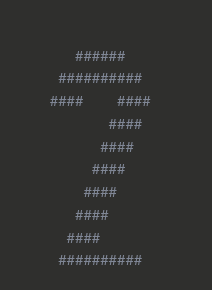

In [16]:
# look at a few different ones
for i in [1, 2]:
    img, label = train_data[i]
    print(f"\n--- Image {i}, Label: {label} ---")
    pixels = img.squeeze().numpy()
    for row in pixels:
        print("".join("##" if p > 0.5 else "  " for p in row))


--- Image 1, Label: 0 ---
                                                        
                                                        
                                                        
                                                        
                                ######                  
                              ##########                
                            ############                
                          ##########  ####              
                      ##############  ######            
                      ########  ####    ####            
                    ########            ####            
                  ########              ######          
                ######                  ######          
                ####                    ######          
              ######                    ######          
              ####                      ######          
              ####                    ######            
    

**Why can't we just feed these pixel values directly into your tiny neural engine from before?**

Because then there would be too much data fed into a sinle input. If you flatten the image to 784 numbers and feed it straight in, the network has no idea that pixel 15 and pixel 16 are next to each other. It just sees a long list of numbers. All spatial structure — the fact that a 7 has a horizontal stroke at the top, or a 0 is a closed loop — is invisible to it. 

You'd also have a weight for every single pixel connection, which explodes fast. One layer connecting 784 inputs to 128 neurons = 784 × 128 = 100,352 weights to learn, just for that one layer. And it still wouldn't understand shapes.

A conv layer sloves this. Instead of connecting every pixel to every neuron it slides a small filter (say 3×3 = 9 weights) across the whole image. Same 9 weights, applied everywhere. The filter is literally w from before, but instead of one dot product on the whole image, it does a dot product on a 3×3 patch, then slides one step right, does it again, slides again, all the way across and down. Every position produces one number. The result is a new grid called a **feature map**

In [21]:
# Before writing conv code a small experiment
import torch
import torch.nn.functional as F

# pretend image a rough vertical edge in the middle
img = torch.tensor([[
    [0., 0., 1., 1.],
    [0., 0., 1., 1.],
    [0., 0., 1., 1.],
    [0., 0., 1., 1.],
]], ).unsqueeze(0)  # shape: [1, 1, 4, 4]  (batch, channel, h, w)

# Hand crafted filter that detects vertical edges
filter = torch.tensor([[
    [[-1., 1.],
     [-1., 1.]]
]])  # shape: [1, 1, 2, 2]


output = F.conv2d(img, filter)
print(output)

tensor([[[[0., 2., 0.],
          [0., 2., 0.],
          [0., 2., 0.]]]])


Notice the output is 3×3 even though the image was 4×4. That's because a 2×2 filter can only fit in 4-2+1 = 3 positions across. Images shrink slightly as they pass the conv filter.

This filter is litteraly like w in out neural network engine. They start random and gradient descent nudges them during training until they become useful detectors. Some end up detecting edges, some curves, some corners — the network figures that out on its own.

In [26]:
import torch.nn as nn

# version 1
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # one conv layer: 1 input channel, 32 filters, 3x3 kernel
        # padding=1 keeps the output the same size as input 28x28
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        

    def forward(self, x):
        # and how data flows through it
        layer = self.conv1(x)
        x = self.relu(layer)
        
        return x

In [31]:
model = CNN()

# testing it with fake image
fake_img = torch.randn(1, 1, 28, 28)  # one image, 1 channel, 28x28
output = model(fake_img)
print(output.shape)

torch.Size([1, 32, 28, 28])


When you put one image in, each of the 32 filters slid across it independently and produced its own 28×28 output. So now instead of one grid of pixel values, you have 32 grids stacked on top of each other — one per filter.

Each of those 32 grids is answering a different question about the image. After training, one grid might look like "where are the vertical edges", another "where are the curves", another "where are the corners". High values = "yes this pattern is here", low values = "nothing here".

"so these 32 filters then are just information about how important are the changes in the picture"
Yes, one small refinement to your mental model: the filters don't detect importance exactly, they detect presence of a pattern. Importance comes later when the final layers decide which patterns actually matter for telling digits apart.

In [30]:
model = CNN()
fake_img = torch.randn(1, 1, 28, 28)
output = model(fake_img)

print(output.shape)          # [1, 32, 28, 28]

# pull out filter 0's response map
filter0 = output[0, 0, :, :]   # batch 0, filter 0, all rows, all cols
print(filter0.shape)            # [28, 28]
#print(filter0)                  # a grid of numbers

torch.Size([1, 32, 28, 28])
torch.Size([28, 28])


In [34]:
import torch.nn as nn

# Version 2
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2) # pool will shrink the spatial size by half
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)               # 28x28 turns 14x14
        x = self.relu(self.conv2(x))
        x = self.pool(x)               # 14x14 turns 7x7
        return x

In [33]:
model = CNN()

# testing it with fake image
fake_img = torch.randn(1, 1, 28, 28)  # one image, 1 channel, 28x28
output = model(fake_img)
print(output.shape)

torch.Size([1, 64, 7, 7])


**Why use ReLU here?**
In the context of your conv layer specifically — the filter does a dot product and gets some number. Negative means "this pattern is absent here", positive means "this pattern is present here". ReLU just kills the "absent" signal and keeps the "present" signal. Clean and simple.

Now we have 64 feature maps each 7×7. The conv part of the network is done.

In [37]:
import torch.nn as nn

# Version 3
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2) # pool will shrink the spatial size by half
        self.relu = nn.ReLU()
        # cuz 64 × 7 × 7 = 3136 numbers in a flat vector 
        self.fc1 = nn.Linear(3136, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)               # 28x28 turns 14x14
        x = self.relu(self.conv2(x))
        x = self.pool(x)               # 14x14 turns 7x7

        # 3136 → 128 neurons → 10 outputs (one per digit)
        x = x.flatten(start_dim=1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [38]:
model = CNN()
fake_img = torch.randn(1, 1, 28, 28)
output = model(fake_img)
print(output.shape)

torch.Size([1, 10])


**Why no ReLU after fc1**

After fc2 you have 10 numbers, one per digit. You want to turn those into probabilities — "I'm 90% sure this is a 7, 5% sure it's a 1" etc. The way you do that is with softmax, which takes any 10 numbers and squishes them into 10 probabilities that add up to 1.

If you put ReLU before softmax, you'd kill all the negative outputs — but those negatives are meaningful. A very negative score for digit 3 means "definitely not a 3". If you zero it out you're throwing away useful information before softmax gets to compare them all.

In [ ]:
# The whole 'pipeline - COMPLETED CNN
[1, 1, 28, 28] → conv1+relu+pool → [1, 32, 14, 14]
               → conv2+relu+pool → [1, 64, 7, 7]
               → flatten         → [1, 3136]
               → fc1+relu        → [1, 128]
               → fc2             → [1, 10]

## Now the training loop

Previously in engine.ipynb i did:
1. forward pass
2. loss
3. backward
4. update weights
5. clear gradients

The only differences when using your CNN with real data are small quality-of-life improvements PyTorch gives you. Instead of updating every weight manually like W1 -= lr * W1.grad, you use an optimizer which does that for all weights in one line. And instead of MSE loss you use CrossEntropyLoss which is better suited for classification.

In [43]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)

In [50]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CNN()
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for images, labels in train_loader:
    # move data to GPU
    images, labels = images.to(device), labels.to(device)

    # clear gradients — why at the start?
    optimizer.zero_grad()
    
    outputs = model(images)

    # Loss - using classification, 
    # internally does softmax and figures out how wrong you were
    loss = criterion(outputs, labels)

    # Backward
    loss.backward()

    # Updaing weight - replacing the manual we had before
    optimizer.step()
print(f"loss: {loss.item():.4f}")

loss: 0.0201


In [44]:
for epoch in range(1):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch}, loss: {loss.item():.4f}")

epoch 0, loss: 0.0357


That's a great result for one epoch. The loss starting low-ish and ending at 0.0357 means the network learned something real in just one pass through the data.

In [45]:
# Adding a print every 200 batches so you can watch it learn in real time
for epoch in range(3):
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        if i % 200 == 0:
            print(f"epoch {epoch}, batch {i}, loss: {loss.item():.4f}")

epoch 0, batch 0, loss: 0.0625
epoch 0, batch 200, loss: 0.0197
epoch 0, batch 400, loss: 0.0091
epoch 0, batch 600, loss: 0.0673
epoch 0, batch 800, loss: 0.0246
epoch 1, batch 0, loss: 0.0638
epoch 1, batch 200, loss: 0.0050
epoch 1, batch 400, loss: 0.1404
epoch 1, batch 600, loss: 0.0044
epoch 1, batch 800, loss: 0.0631
epoch 2, batch 0, loss: 0.0146
epoch 2, batch 200, loss: 0.0446
epoch 2, batch 400, loss: 0.0254
epoch 2, batch 600, loss: 0.0654
epoch 2, batch 800, loss: 0.0104


The loss is generally low and the model is learning — but notice it's jumping around a lot, like 0.0050 then 0.1404 then 0.0044. That's normal — each batch is a different random set of 64 images, so some batches are harder than others. If you averaged across all batches it would show a cleaner downward trend.


In [54]:
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=True)

In [55]:
correct = 0
total = 0

with torch.no_grad():   # why do you think we use no_grad here?
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # outputs is [64, 10] — 10 scores per image
        # you need to pick the highest score as the prediction
        predicted = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"accuracy: {100 * correct / total:.1f}%")

accuracy: 98.5%


**Why add no_grad now?**
no_grad — During evaluation you're just checking how good the model is, not teaching it anything. Without no_grad, PyTorch would still track every operation and build the computation graph ready for loss.backward() — wasting memory and time for no reason. no_grad tells it "don't bother, we're just looking".

**argmax(dim=1) picks the index of the highest score — why index and not the score itself?**
argmax — You have 10 scores like [0.1, 0.05, 0.02, 0.8, 0.01, ...] and you don't care about the actual score values, you just want to know which digit the model is most confident about. argmax gives you the index of the highest value — so if position 3 is highest, the model thinks it's a 3. Then you just compare that to the true label.
